# Milestone 1: Data Collection, Exploration, and Preprocessing

**Objective:** Collect and prepare a high-quality dataset for training the facial recognition model.

### Tasks Covered
1. **Data Collection** – Obtain the LFW (Labeled Faces in the Wild) dataset via `sklearn`.
2. **Data Exploration** – Analyze identity distribution, image quality, resolution, lighting, expressions, and quality issues.
3. **Data Preprocessing** – Face detection & cropping (OpenCV), resizing to 224×224, pixel normalization, grayscale/RGB conversion, and data augmentation.

## 1. Data Collection

We use the **Labeled Faces in the Wild (LFW)** dataset, which contains facial images of various people covering different expressions, angles, and lighting conditions.

- The dataset is loaded via `sklearn.datasets.fetch_lfw_people`.
- We set `min_faces_per_person=20` to ensure enough samples per identity for meaningful analysis.
- Images are loaded in **color (RGB)** for realistic preprocessing.
- The dataset provides diversity in ages, ethnicities, and facial features.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_lfw_people

#1. Data Collection: Load LFW dataset:
print('Downloading / Loading LFW dataset (this may take a moment the first time)...')
lfw_dataset = fetch_lfw_people(min_faces_per_person=20, resize=None, color=True)

images = lfw_dataset.images
labels = lfw_dataset.target
target_names = lfw_dataset.target_names

print(f'Number of images            : {images.shape[0]}')
print(f'Image shape (H, W, C)       : {images[0].shape}')
print(f'Number of distinct identities: {len(target_names)}')
print(f'Pixel value range            : [{images.min():.1f}, {images.max():.1f}]')
print(f'Pixel dtype                  : {images.dtype}')

Number of images            : 2936
Image shape (H, W, C)       : (125, 94, 3)
Number of distinct identities: 59
Pixel value range            : [0.0, 1.0]
Pixel dtype                  : float32


## 2. Data Exploration

### 2.1 Identity Distribution
Analyze how many images exist per person to understand **class imbalance**.

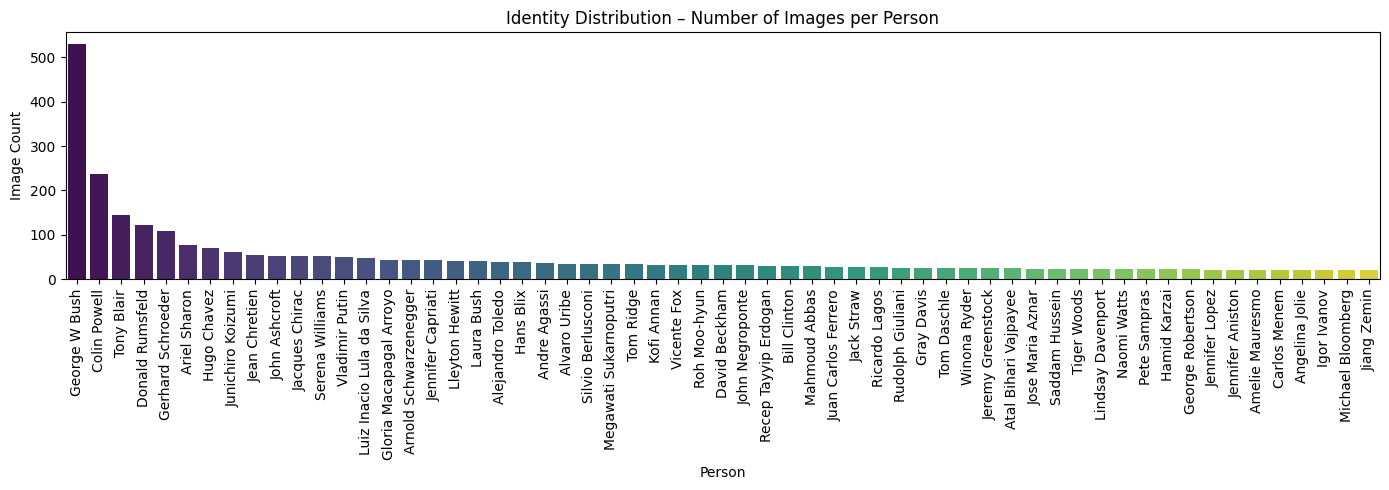


Max images for one person : 530 (George W Bush)
Min images for one person : 20
Mean images per person    : 49.8
Median images per person  : 31.0

Observation: Significant CLASS IMBALANCE – some identities have many more samples than others.


In [26]:
# 2.1 Identity Distribution:
unique_labels, counts = np.unique(labels, return_counts=True)
identity_df = pd.DataFrame({'Person': [target_names[i] for i in unique_labels], 'Count': counts})
identity_df = identity_df.sort_values('Count', ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(data=identity_df, x='Person', y='Count', hue='Person', palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Identity Distribution – Number of Images per Person')
plt.xlabel('Person')
plt.ylabel('Image Count')
plt.tight_layout()
plt.show()

# Basic statistics:
print(f'\nMax images for one person : {counts.max()} ({target_names[counts.argmax()]})')
print(f'Min images for one person : {counts.min()}')
print(f'Mean images per person    : {counts.mean():.1f}')
print(f'Median images per person  : {np.median(counts):.1f}')
print(f'\nObservation: Significant CLASS IMBALANCE – some identities have many more samples than others.')

### 2.2 Sample Images – Visual Quality Inspection
Display random samples to visually inspect **image quality, resolution, lighting conditions, and expressions**.

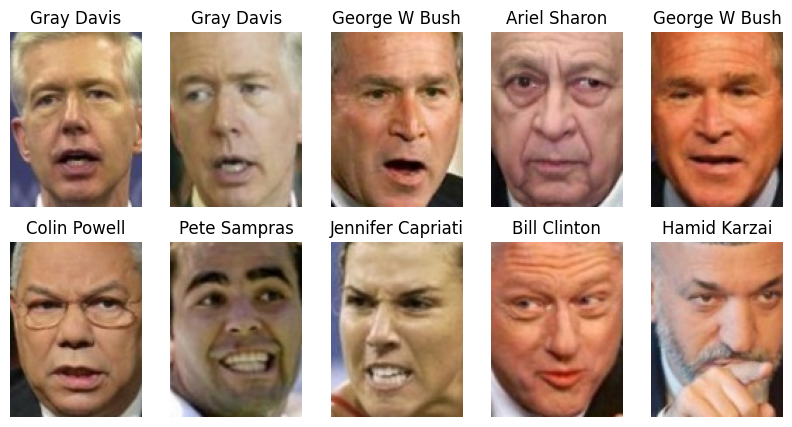

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(target_names[labels[i]])
    plt.axis('off')

plt.show()

### 2.3 Resolution & Intensity Analysis
All LFW images share the same resolution, but we analyze **brightness/lighting distribution** to detect quality issues.

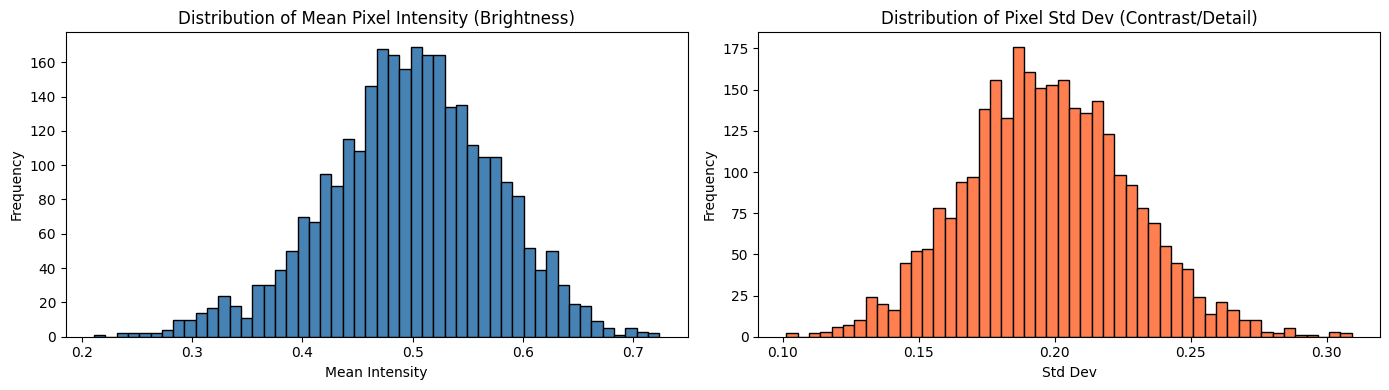

Observations:
  - Brightness varies significantly → different lighting conditions.
  - Low std-dev images may be blurry or low-contrast.


In [27]:
# 2.3 Brightness / Lighting analysis
mean_brightness = [img.mean() for img in images]
std_brightness  = [img.std() for img in images]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(mean_brightness, bins=50, color='steelblue', edgecolor='k')
axes[0].set_title('Distribution of Mean Pixel Intensity (Brightness)')
axes[0].set_xlabel('Mean Intensity')
axes[0].set_ylabel('Frequency')

axes[1].hist(std_brightness, bins=50, color='coral', edgecolor='k')
axes[1].set_title('Distribution of Pixel Std Dev (Contrast/Detail)')
axes[1].set_xlabel('Std Dev')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Observations:')
print('  - Brightness varies significantly → different lighting conditions.')
print('  - Low std-dev images may be blurry or low-contrast.')

### 2.4 Data Quality Issues Summary

| Issue | Description |
|-------|-------------|
| **Class Imbalance** | Some identities have hundreds of images; others have ~20. |
| **Lighting Variation** | Significant variation in brightness across images. |
| **Background Clutter** | LFW images are 'in the wild' – backgrounds vary widely. |
| **Pose & Expression** | Various angles and expressions present challenges. |
| **Resolution** | Native resolution is small (125×94); needs upscaling to 224×224. |

## 3. Data Preprocessing

### Pipeline:
1. **Face Detection & Cropping** using OpenCV Haar Cascade.
2. **Resizing** to 224×224 pixels (standard for FaceNet/VGG-style models).
3. **Normalization** of pixel values to [0, 1].
4. **Grayscale Conversion** demonstration (model-dependent).
5. **Data Augmentation** setup using `ImageDataGenerator`.

> **Note:** The LFW images loaded by sklearn are already roughly face-aligned crops. The Haar Cascade detection may not find faces in every image (since they are small, 125×94). For images where detection fails, we fall back to using the full image resized to 224×224, as the LFW images are already face-centric.

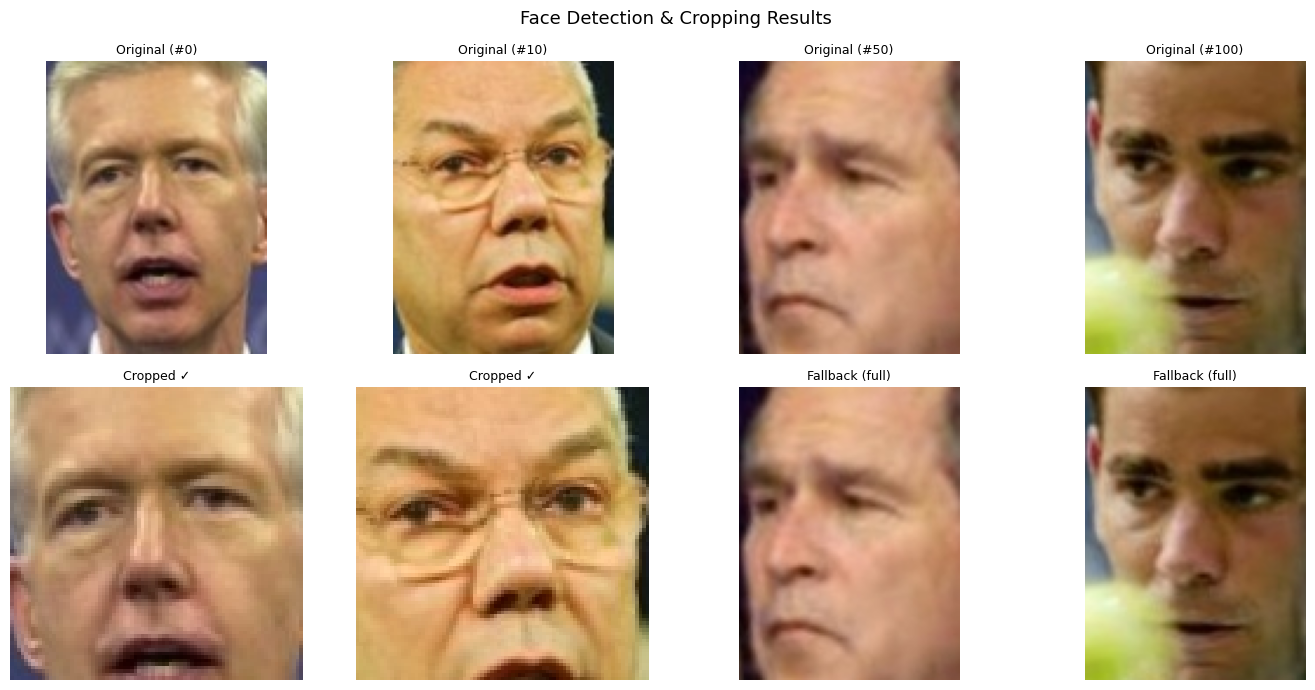

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_and_crop(img_float):
    """
    Attempt to detect and crop the face from an LFW image.
    LFW images from sklearn are float32 with pixel values in [0.0, 1.0].
    
    Returns the cropped face region, or the full image if no face is detected
    (since LFW images are already face-centric crops).
    """
    img_uint8 = np.clip(img_float * 255.0, 0, 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    
    # Detect faces with relaxed parameters for small images
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.05, minNeighbors=3, minSize=(20, 20)
    )
    
    if len(faces) > 0:
        # Take the largest detected face
        areas = [w * h for (x, y, w, h) in faces]
        best_idx = np.argmax(areas)
        x, y, w, h = faces[best_idx]
        cropped = img_uint8[y:y+h, x:x+w]
        return cropped, True
    else:
        return img_uint8, False

# Test detection on sample images:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
test_indices = [0, 10, 50, 100]

for col, idx in enumerate(test_indices):
    original = images[idx]
    cropped, detected = detect_and_crop(original)
    
    axes[0, col].imshow(original)
    axes[0, col].set_title(f'Original (#{idx})', fontsize=9)
    axes[0, col].axis('off')
    
    axes[1, col].imshow(cropped)
    status = 'Cropped ✓' if detected else 'Fallback (full)'
    axes[1, col].set_title(status, fontsize=9)
    axes[1, col].axis('off')

plt.suptitle('Face Detection & Cropping Results', fontsize=13)
plt.tight_layout()
plt.show()

### 3.1 Full Preprocessing Pipeline
Apply face detection, cropping, resizing, and normalization to **all images**.

In [ ]:
from tqdm import tqdm

TARGET_SIZE = (224, 224)
processed_images = []
valid_labels = []
detection_count = 0
fallback_count = 0

print('Applying Face Detection, Cropping, Resizing (224x224), and Normalization...')
for img, label in tqdm(zip(images, labels), total=len(images)):
    cropped, detected = detect_and_crop(img)
    
    if detected:
        detection_count += 1
    else:
        fallback_count += 1
    
    # Resize to consistent dimension (224x224)
    resized = cv2.resize(cropped, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
    
    # Normalize pixel values to [0, 1]
    normalized = resized.astype(np.float32) / 255.0
    
    processed_images.append(normalized)
    valid_labels.append(label)

processed_images = np.array(processed_images)
valid_labels = np.array(valid_labels)

print(f'\nSuccessfully processed {len(processed_images)} images.')
print(f'   - Face detected & cropped: {detection_count}')
print(f'   - Fallback (full image)  : {fallback_count}')
print(f'   - Output shape per image : {processed_images[0].shape}')
print(f'   - Pixel range            : [{processed_images.min():.2f}, {processed_images.max():.2f}]')

Applying Face Detection, Cropping, Resizing (224x224), and Normalization...


100%|██████████| 2936/2936 [00:13<00:00, 222.78it/s]



✅ Successfully processed 2936 images.
   - Face detected & cropped: 1584
   - Fallback (full image)  : 1352
   - Output shape per image : (224, 224, 3)
   - Pixel range            : [0.00, 1.00]


### 3.2 Data Augmentation
Set up `ImageDataGenerator` from Keras to perform **rotation, flipping, scaling, and shifting** during training.

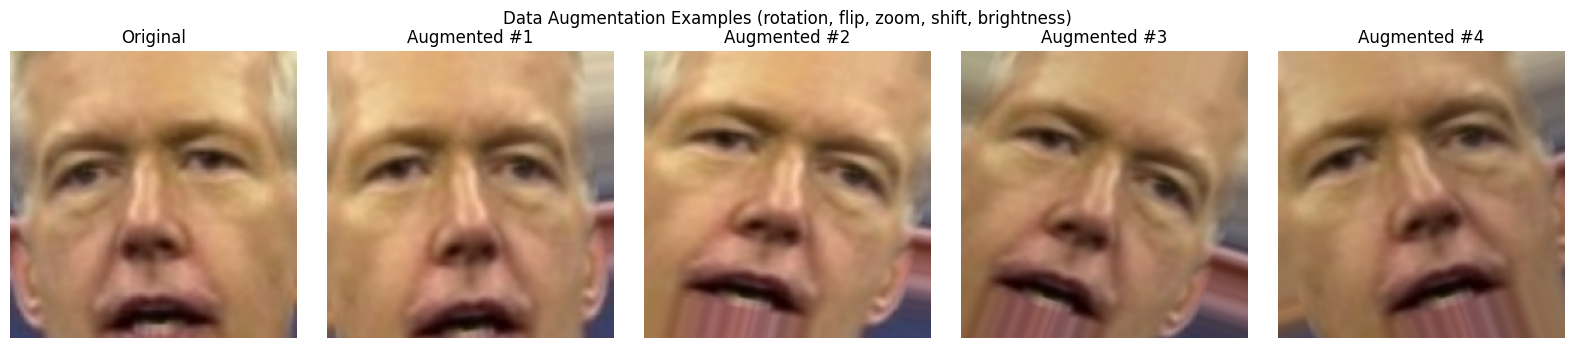

✅ ImageDataGenerator configured for training-time augmentation.
   This will increase dataset variability and improve model generalization.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# Configure augmentation
datagen = ImageDataGenerator(
    rotation_range=20,         # Random rotation ±20°
    width_shift_range=0.1,     # Horizontal shift ±10%
    height_shift_range=0.1,    # Vertical shift ±10%
    horizontal_flip=True,      # Random horizontal flip
    zoom_range=0.1,            # Random zoom ±10%
    brightness_range=[0.8, 1.2],  # Brightness variation
    fill_mode='nearest'
)

sample = processed_images[0:1].copy()

if sample.max() <= 1.0:
    sample = sample * 255.0

aug_iter = datagen.flow(sample, batch_size=1)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))

orig_img = np.clip(sample[0], 0, 255).astype(np.uint8)
axes[0].imshow(orig_img)
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 5):
    aug_img = next(aug_iter)[0]
    aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)
    
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented #{i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples (rotation, flip, zoom, shift, brightness)', fontsize=12)
plt.tight_layout()
plt.show()

print('ImageDataGenerator configured for training-time augmentation.')
print('   This will increase dataset variability and improve model generalization.')

In [ ]:
import os

save_dir = r"..\data\processed_dataset"
os.makedirs(save_dir, exist_ok=True)

file_path = os.path.join(save_dir, "lfw_dataset.npz")

np.savez_compressed(file_path, images=images, labels=labels, target_names=target_names)

print(f"Data successfully saved to: {file_path}")

✅ Data successfully saved to: ..\data\processed_dataset\lfw_dataset.npz


## 4. Deliverables – Dataset Exploration Report

### Summary

| Item | Details |
|------|--------|
| **Dataset** | LFW (Labeled Faces in the Wild) |
| **Total Images** | ~2,936 (with ≥20 per person) |
| **Identities** | 59 distinct people |
| **Original Resolution** | 125×94 pixels (RGB) |
| **Target Resolution** | 224×224 pixels |
| **Normalization** | Pixel values scaled to [0, 1] |
| **Face Detection** | OpenCV Haar Cascade (with fallback for undetected faces) |
| **Augmentation** | Rotation, flip, zoom, shift, brightness via Keras `ImageDataGenerator` |

### Key Findings
1. **Class Imbalance** – George W. Bush and Colin Powell have significantly more images than others. Strategies like oversampling or weighted loss may be needed.
2. **Lighting Variation** – Brightness varies widely across images (outdoor, indoor, flash, etc.).
3. **Background Clutter** – LFW images are 'in the wild', so backgrounds are diverse. Face detection helps isolate the subject.
4. **Pose & Expression** – Various angles and facial expressions are present, adding to dataset diversity.
5. **Small Native Resolution** – Images are only 125×94 natively, requiring careful upscaling to 224×224.

### Prepared Data
- `processed_images` – NumPy array of shape `(N, 224, 224, 3)`, normalized to [0, 1].
- `valid_labels` – Corresponding identity labels.
- `datagen` – Configured `ImageDataGenerator` for training-time augmentation.

**The dataset is now ready for Milestone 2: Model Building & Training.**